In [47]:
import numpy as np
import matplotlib.pyplot as plt

In [48]:
def setup_tridiagonal_matrix(x, y):
    n = len(x)
    
    # Step 2 Step sizes between data points
    h = np.diff(x)
    
    # Initialize the tridiagonal matrix coefficients
    A = np.zeros(n - 2)  # Subdiagonal
    B = np.zeros(n - 2)  # Main diagonal
    C = np.zeros(n - 2)  # Superdiagonal
    D = np.zeros(n - 2)  # Right-hand side vector
    
    # Populate the tridiagonal matrix coefficients
    for i in range(1, n - 1):
        A[i - 1] = h[i-1]                                               # Subdiagonal   the below
        B[i - 1] = 2*(h[i-1] + h[i])                                    # Main diagonal
        C[i - 1] = h[i]                                                 # Superdiagonal   the above
        D[i - 1] = 6*( ((y[i+1]-y[i])/h[i]) - ((y[i]-y[i-1])/h[i-1]) )  # Right-hand side vector
                      
    return A, B, C, D

In [49]:
def thomas_algorithm(a, b, c, d):
    """
    Solve the tridiagonal system using the Thomas algorithm.
    a: sub-diagonal elements (length n-1)
    b: main diagonal elements (length n)
    c: super-diagonal elements (length n-1)
    d: right-hand side (length n)
    Returns: solution vector x of length n
    x is the second derivative, M
    """
    n = len(b)
    a = np.copy(a)
    b = np.copy(b)
    c = np.copy(c)
    d = np.copy(d)
    
    # Forward elimination
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
        
    # Back substitution
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
        
    return x

In [50]:
def evaluate_spline(x, y, M, x_eval):
    x_eval = np.array(x_eval, dtype=float)
    y_eval = np.zeros_like(x_eval)

    for k in range(len(x_eval)):
        current_x = x_eval[k]

        if current_x == x[-1]:
            i = len(x) - 2
        else:
            i = np.searchsorted(x, current_x) - 1

            if i < 0:
                i = 0
            elif i > len(x) - 2:
                i = len(x) - 2

        h = x[i + 1] - x[i]

        term1 = M[i] * (x[i + 1] - current_x)**3 / (6 * h)
        term2 = M[i + 1] * (current_x - x[i])**3 / (6 * h)
        term3 = (y[i] - M[i] * h**2 / 6) * (x[i + 1] - current_x) / h
        term4 = (y[i + 1] - M[i + 1] * h**2 / 6) * (current_x - x[i]) / h

        y_eval[k] = term1 + term2 + term3 + term4

    return y_eval


"""
why you needed to use an AI:
    I was having trouble figuring out how to identify which interval 
    each new x-value belonged to when evaluating the spline.

the AI prompt you used:
    Here is my code (i gave it the code i had at the time), does this place the interior point at the correct spot.
    It didnt and it told me to use searchsorted

which AI you used:
    ChatGPT
"""

'\nwhy you needed to use an AI:\n    I was having trouble figuring out how to identify which interval \n    each new x-value belonged to when evaluating the spline.\n\nthe AI prompt you used:\n    Here is my code (i gave it the code i had at the time), does this place the interior point at the correct spot.\n    It didnt and it told me to use searchsorted\n\nwhich AI you used:\n    ChatGPT\n'

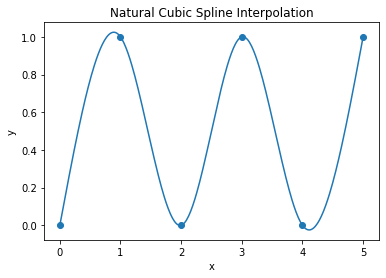

In [51]:
def main():
    # Step 1: Define known data points
    x = np.array([0., 1., 2., 3., 4., 5.])
    y = np.array([0., 1., 0., 1., 0., 1.])
    
    # Step 3A Set up tridiagonal matrix
    A, B, C, D = setup_tridiagonal_matrix(x, y)
    
    # Step 3B solve the matrix using the thomas algortithm
    M_interior = thomas_algorithm(A, B, C, D)
    
    # Step 3C second derivatives are computhed with
    # natural spline boundary conditions: M0 = Mn-1 = 0
    n = len(x)
    M = np.zeros(n)
    M[1:n-1] = M_interior

    # New x-points for smooth curve
    x_eval = np.linspace(x[0], x[-1], 300)
    
    # Step 4 evaulate the spline at the new points
    y_eval = evaluate_spline(x, y, M, x_eval)



    # Step 5: Plot the results
    plt.figure()
    plt.scatter(x, y)
    plt.plot(x_eval, y_eval)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Natural Cubic Spline Interpolation")
    plt.show()
    
    return 0

if __name__ == "__main__":
    main()